In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(f"Nombre de lignes (clients) : {df.shape[0]}")
print(f"Nombre de colonnes (variables) : {df.shape[1]}")
df.info()

Nombre de lignes (clients) : 7043
Nombre de colonnes (variables) : 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-nul

In [4]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()

np.int64(11)

In [5]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [6]:
# Conversion en numérique (les valeurs vides deviennent NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remplacement des NaN par 0 (logique : tenure=0 donc pas encore facturé)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Vérification
print(f"Valeurs manquantes restantes : {df['TotalCharges'].isna().sum()}")
print(f"Type de la colonne : {df['TotalCharges'].dtype}")

Valeurs manquantes restantes : 0
Type de la colonne : float64


In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

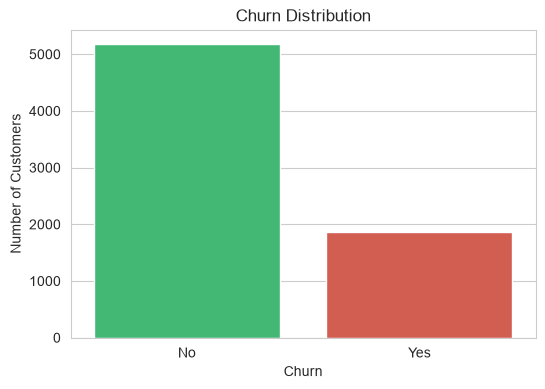

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [10]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


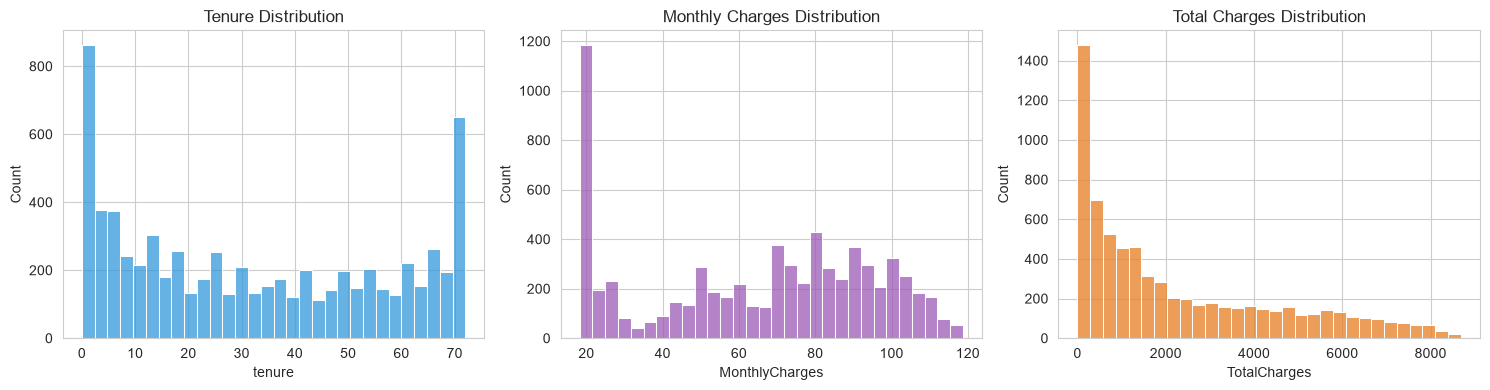

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['tenure'], bins=30, ax=axes[0], color='#3498db')
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1], color='#9b59b6')
axes[1].set_title('Monthly Charges Distribution')

sns.histplot(df['TotalCharges'], bins=30, ax=axes[2], color='#e67e22')
axes[2].set_title('Total Charges Distribution')

plt.tight_layout()
plt.show()

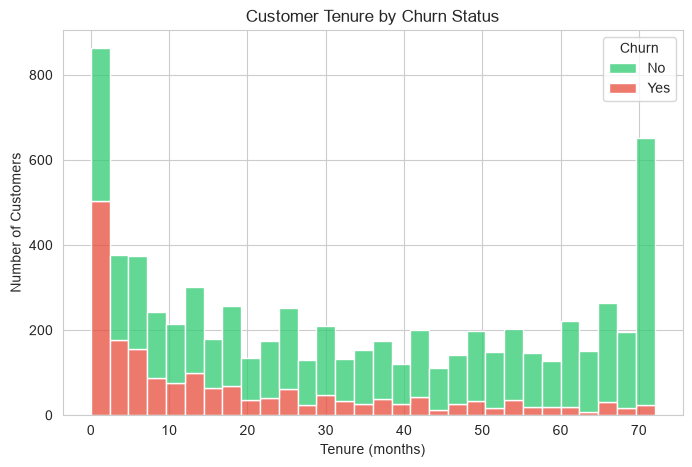

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

## Key observation: tenure and churn

Customers with low tenure (0-5 months) show a much higher churn rate 
than long-time customers (60+ months). This suggests the first months 
are critical for retention.

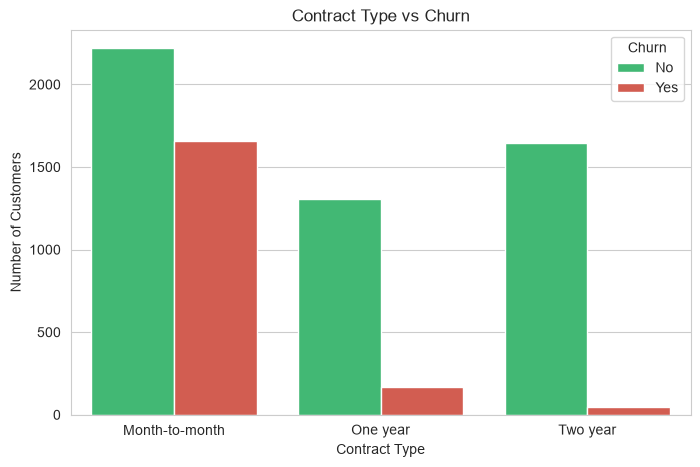

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

In [17]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Key observation: contract type and churn

Contract type shows one of the strongest relationships with churn:
- Month-to-month: 42.7% churn rate
- One year: 11.3% churn rate  
- Two year: 2.8% churn rate

Customers without a long-term commitment are ~15x more likely to churn 
than customers on a two-year contract.

In [21]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [22]:
df.groupby('InternetService')['MonthlyCharges'].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

## Key observation: internet service type and churn

Fiber optic customers have the highest churn rate (41.9%), despite (or 
because of) paying significantly more on average ($91.50/month vs 
$58.10 for DSL). This suggests price sensitivity or competitive 
pressure may be driving churn among fiber customers.

In [23]:
# Temporary copy for the heatmap only (final encoding will be done more carefully in the next step)
df_corr = df.copy()

# Encode binary Yes/No variables as 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0})

# Encode gender
df_corr['gender'] = df_corr['gender'].map({'Male': 1, 'Female': 0})

# One-hot encoding for multi-category variables
df_corr = pd.get_dummies(df_corr, columns=['InternetService', 'Contract', 'PaymentMethod',
                                              'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                                              'DeviceProtection', 'TechSupport', 'StreamingTV',
                                              'StreamingMovies'], drop_first=True)

# Drop customerID (identifier, not a real feature)
df_corr = df_corr.drop('customerID', axis=1)

df_corr.shape

(7043, 31)

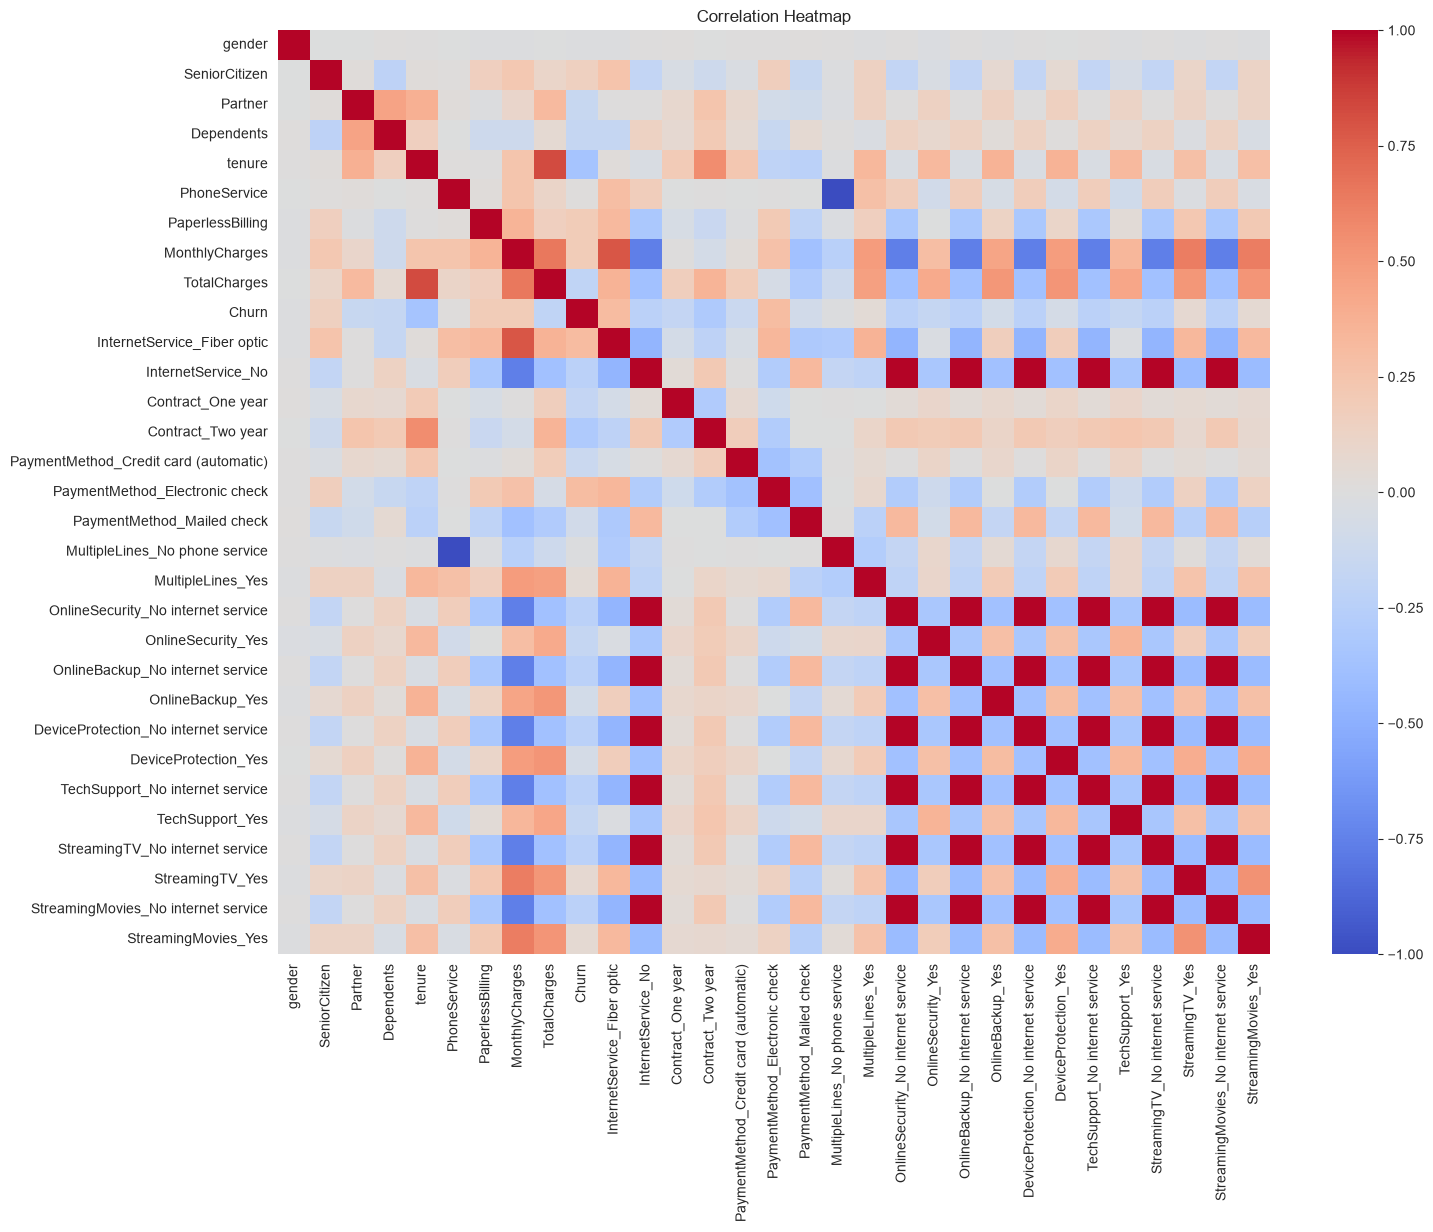

In [24]:
plt.figure(figsize=(16, 12))
correlation_matrix = df_corr.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [25]:
# Correlation with Churn only, sorted from strongest to weakest
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)
churn_correlation

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


## Summary: strongest predictors of churn

Based on the correlation analysis, the strongest predictors are:
- **tenure** (-0.35): longer-tenured customers are far less likely to churn
- **Contract_Two year** (-0.30): long-term contracts strongly reduce churn
- **InternetService_Fiber optic** (0.31): fiber customers churn more, likely due to higher price
- **PaymentMethod_Electronic check** (0.30): a new pattern worth investigating further

Note: TotalCharges' negative correlation is partly explained by its 
mechanical link to tenure (longer tenure = higher cumulative charges).